<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/ARIMA%20Grupo%20M%C3%A9xico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARIMA Grupo México

#Librerías

In [161]:
!pip install pmdarima

In [162]:
!pip install arch

In [163]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error
from arch import arch_model
from sklearn.metrics import mean_absolute_percentage_error
from tabulate import tabulate

#Grupo México

In [164]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01', end ='2026-06-26')

/tmp/ipykernel_17073/382611023.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01', end ='2026-06-26')
[*********************100%***********************]  1 of 1 completed


In [165]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

In [166]:
#Para almacenar los datos por cualquier cosa
df.to_csv("GMEXICOB_historico.csv")

#Rendimientos

Vamos a usar los rendimientos logarítmicos para nuestros cálculos

In [167]:
#Obtener datos
precios = df['Close']

In [168]:
print(precios)

Date
2024-01-02     84.612030
2024-01-03     81.479942
2024-01-04     80.067780
2024-01-05     82.376129
2024-01-08     83.154625
                 ...    
2026-06-19    207.500000
2026-06-22    210.360001
2026-06-23    206.100006
2026-06-24    196.639999
2026-06-25    202.990005
Name: Close, Length: 621, dtype: float64


In [169]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
                ...   
2026-06-19   -0.031826
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
Name: Rendimientos_Log, Length: 621, dtype: float64


In [170]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-19   -0.031826
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
Name: Rendimientos_Log, Length: 620, dtype: float64


#ARIMA

In [171]:
#Nuestro parámetros son p=0, d=0 y q=0
#Aplicamos ARIMA con la función que ya trae Python

modelo0 = ARIMA(df['Rendimientos_Log'].dropna(), order=(0,0,0))
resultado0 = modelo0.fit()

print(resultado0.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  620
Model:                          ARIMA   Log Likelihood                1478.280
Date:                Sun, 05 Jul 2026   AIC                          -2952.561
Time:                        22:45:09   BIC                          -2943.702
Sample:                             0   HQIC                         -2949.117
                                - 620                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0014      0.001      1.526      0.127      -0.000       0.003
sigma2         0.0005   1.54e-05     32.317      0.000       0.000       0.001
Ljung-Box (L1) (Q):                   4.64   Jarque-

In [172]:
#Hacemos la prueba para saber si necesitamos utilizar GARCH o no
#Si p<0.5 si se requiere, si p>0.5 no se requiere

from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(df['Rendimientos_Log'].dropna())

print("LM Statistic:", arch_test[0])
print("p-value:", arch_test[1])

LM Statistic: 7.523760314482634
p-value: 0.6752445996983172


In [173]:
#Confirmaremos con Auto ARIMA que el modelo (0,0,0) es el mejor
Arima = auto_arima(df['Rendimientos_Log'])
print(Arima)

 ARIMA(0,0,1)(0,0,0)[0] intercept


In [174]:
#Como no fue el mejor vamos a evaluar más opciones de modelos ARIMA
#El resultado con menos AIC es mejor
for orden in [(0,0,0),(0,0,1)]:
  modelo01 = ARIMA(df['Rendimientos_Log'].dropna(),order=orden)
  resultado01 = modelo01.fit()

  print("ARIMA", orden, "AIC:", resultado01.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA (0, 0, 0) AIC: -2952.560976321336
ARIMA (0, 0, 1) AIC: -2955.380202531571


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [175]:
modelo1 = ARIMA(df['Rendimientos_Log'].dropna(),
               order=(0,0,1))

resultado1 = modelo1.fit()

print(resultado1.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  620
Model:                 ARIMA(0, 0, 1)   Log Likelihood                1480.690
Date:                Sun, 05 Jul 2026   AIC                          -2955.380
Time:                        22:45:12   BIC                          -2942.091
Sample:                             0   HQIC                         -2950.215
                                - 620                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0014      0.001      1.679      0.093      -0.000       0.003
ma.L1         -0.0894      0.037     -2.407      0.016      -0.162      -0.017
sigma2         0.0005   1.58e-05     31.297      0.0

In [176]:
#Hacemos prueba para saber si se requiere GARCH o no
residuos = resultado1.resid

for lag in [5,10,15,20]:
    lm, pvalue, _, _ = het_arch(residuos, nlags=lag)
    print(f"Lag={lag}: p-value={pvalue}")

Lag=5: p-value=0.4392959115506073
Lag=10: p-value=0.7730412602352932
Lag=15: p-value=0.933337119325285
Lag=20: p-value=0.9780067963762328


#Prueba con datos de entrenamiento

In [178]:
#Vamos a ver cuáles son los precios reales de los últimos 5 días
precios_reales = precios[-100:]
print(precios_reales)

Date
2026-01-29    206.218124
2026-01-30    190.026947
2026-02-03    205.961899
2026-02-04    201.142990
2026-02-05    198.088043
                 ...    
2026-06-19    207.500000
2026-06-22    210.360001
2026-06-23    206.100006
2026-06-24    196.639999
2026-06-25    202.990005
Name: Close, Length: 100, dtype: float64


In [179]:
train = precios[:-100]
test = precios[-100:]

In [180]:
ppredictions = resultado1.forecast(steps=100)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [181]:
ultimo_precio = train.iloc[-100]

pprecios_pred = []
precio_actual = ultimo_precio

for r in ppredictions:
    precio_actual = precio_actual * np.exp(r)
    pprecios_pred.append(precio_actual)

In [182]:
comparacion = pd.DataFrame({
    "Real": test,
    "Pronosticado": pprecios_pred
})

print(comparacion)

                  Real  Pronosticado
Date                                
2026-01-29  206.218124    123.654194
2026-01-30  190.026947    123.828612
2026-02-03  205.961899    124.003276
2026-02-04  201.142990    124.178187
2026-02-05  198.088043    124.353344
...                ...           ...
2026-06-19  207.500000    141.372054
2026-06-22  210.360001    141.571464
2026-06-23  206.100006    141.771155
2026-06-24  196.639999    141.971128
2026-06-25  202.990005    142.171383

[100 rows x 2 columns]


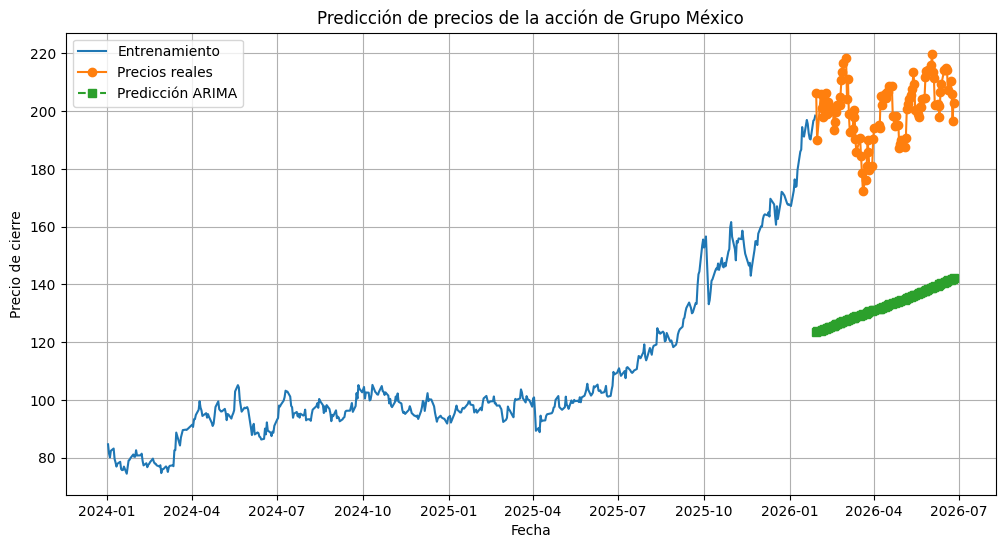

In [183]:
plt.figure(figsize=(12,6))

# Datos de entrenamiento
plt.plot(train.index, train,
         label='Entrenamiento')

# Datos reales
plt.plot(test.index, test,
         marker='o', label='Precios reales')

# Predicción
plt.plot(test.index, pprecios_pred,
         marker='s', linestyle='--',
         label='Predicción ARIMA')

plt.title('Predicción de precios de la acción de Grupo México')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.legend()
plt.grid(True)

plt.show()

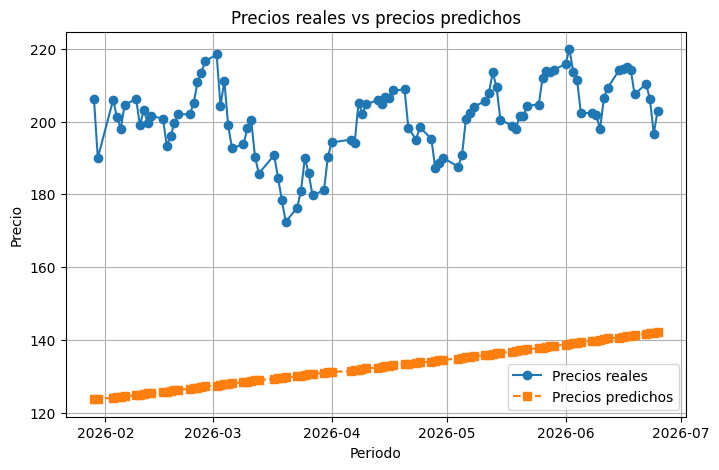

In [184]:
plt.figure(figsize=(8,5))

plt.plot(precios_reales.index, precios_reales,
         marker='o', label='Precios reales')

plt.plot(precios_reales.index, pprecios_pred,
         marker='s', linestyle='--', label='Precios predichos')

plt.title('Precios reales vs precios predichos')
plt.xlabel('Periodo')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)

plt.show()

##Estadísticos de Bondad de Ajuste

###Error Cuadrático Medio (RMSE)

In [185]:
rmse = np.sqrt(mean_squared_error(precios_reales, pprecios_pred))
print(f"RMSE = {rmse:.2f}")

RMSE = 68.95


In [186]:
rmse_porcentaje = (rmse / precios_reales.mean()) * 100
print(f"% RMSE Monte Carlo: {rmse_porcentaje:.4f} %")

% RMSE Monte Carlo: 34.3069 %


###Error Cuadrático Medio (MAE)

In [187]:
mae = mean_absolute_error(precios_reales, pprecios_pred)
print(f"MAE = {mae: .2f}")

MAE =  68.27


In [188]:
mae_porcentaje = (mae /precios_reales.mean()) * 100
print(f"% MAE Monte Carlo: {mae_porcentaje:.4f} %")

% MAE Monte Carlo: 33.9715 %


###Error Porcentual Absoluto Medio (MAPE)

In [189]:
mape = mean_absolute_percentage_error(precios_reales, pprecios_pred) * 100
print(f"MAPE = {mape: .4f} %")

MAPE =  33.8490 %


#Predicción de Precio del día siguiente (29/06/26)


In [190]:
#Predicciones pero de los rendimientos log únicamente para el día siguiente

prediction = resultado1.forecast(steps=1)
print(prediction)

620   -0.000904
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [191]:
#Vamos a convertir los rendimientos en precios
ultimo_precio = precios.iloc[-1]   # Último precio conocido

precio_pred = []
precio_actual = ultimo_precio

for r in prediction:
    precio_actual = precio_actual * np.exp(r)
    precio_pred.append(precio_actual)

In [192]:
#Prediccion precio del siguiente día de cotizacion (29/06/26)
precio_pred = pd.Series(precio_pred, index=prediction.index)

print(precio_pred)

620    202.806557
dtype: float64


##Estadísticos Bonda de Ajuste

In [193]:
#Obtener datos
hoy = yf.download('GMEXICOB.MX', start='2026-06-29', end ='2026-06-30')

/tmp/ipykernel_17073/1590919340.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hoy = yf.download('GMEXICOB.MX', start='2026-06-29', end ='2026-06-30')
[*********************100%***********************]  1 of 1 completed


In [194]:
# Eliminar nivel del ticker
hoy.columns = hoy.columns.droplevel(1)

In [195]:
Precio_hoy = hoy['Close']
print(Precio_hoy)

Date
2026-06-29    201.130005
Name: Close, dtype: float64


In [196]:
#Para almacenar los datos por cualquier cosa
hoy.to_csv("GMEXICOB_29_06_26.csv")

###Error Cuadrático Medio (RMSE)

In [197]:
rmse = np.sqrt(mean_squared_error(hoy['Close'], precio_pred))
print(f"RMSE = {rmse:.2f}")

RMSE = 1.68


In [198]:
rmse_porcentaje = (rmse / Precio_hoy) * 100
print(f"% RMSE ARIMA: {rmse_porcentaje.iloc[0]:.4f} %")

% RMSE ARIMA: 0.8336 %


###Error Cuadrático Medio (MAE)

In [199]:
mae = mean_absolute_error(hoy['Close'], precio_pred)
print(f"MAE = {mae: .2f}")

MAE =  1.68


In [200]:
mae_porcentaje = (mae / Precio_hoy) * 100
print(f"% MAE ARIMA: {mae_porcentaje.iloc[0]:.4f} %")

% MAE ARIMA: 0.8336 %


###Error Porcentual Absoluto Medio (MAPE)

In [201]:
mape = mean_absolute_percentage_error(hoy['Close'], precio_pred) * 100
print(f"MAPE = {mape: .4f} %")

MAPE =  0.8336 %


#Predicción para 100 días desde el 29/06/26

In [202]:
predictions = resultado1.forecast(steps=100)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [203]:
ultimo_precio = precios.iloc[-1]

precios_pred = []
precio_actual = ultimo_precio

for r in predictions:
    precio_actual = precio_actual * np.exp(r)
    precios_pred.append(precio_actual)

In [204]:
fechas_pred = pd.date_range(
    start='2026-06-29',
    periods=100,
    freq='B' #Porque trabajamos con precios de la BMV
)

In [205]:
print(fechas_pred)
print(precios_pred)

DatetimeIndex(['2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02',
               '2026-07-03', '2026-07-06', '2026-07-07', '2026-07-08',
               '2026-07-09', '2026-07-10', '2026-07-13', '2026-07-14',
               '2026-07-15', '2026-07-16', '2026-07-17', '2026-07-20',
               '2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24',
               '2026-07-27', '2026-07-28', '2026-07-29', '2026-07-30',
               '2026-07-31', '2026-08-03', '2026-08-04', '2026-08-05',
               '2026-08-06', '2026-08-07', '2026-08-10', '2026-08-11',
               '2026-08-12', '2026-08-13', '2026-08-14', '2026-08-17',
               '2026-08-18', '2026-08-19', '2026-08-20', '2026-08-21',
               '2026-08-24', '2026-08-25', '2026-08-26', '2026-08-27',
               '2026-08-28', '2026-08-31', '2026-09-01', '2026-09-02',
               '2026-09-03', '2026-09-04', '2026-09-07', '2026-09-08',
               '2026-09-09', '2026-09-10', '2026-09-11', '2026-09-14',
      

In [206]:
pronosticos = pd.DataFrame({
    "Fecha": fechas_pred,
    "Precio pronosticado": precios_pred
})

print(pronosticos)

        Fecha  Precio pronosticado
0  2026-06-29           202.806557
1  2026-06-30           203.092623
2  2026-07-01           203.379091
3  2026-07-02           203.665964
4  2026-07-03           203.953242
..        ...                  ...
95 2026-11-09           231.865808
96 2026-11-10           232.192863
97 2026-11-11           232.520378
98 2026-11-12           232.848356
99 2026-11-13           233.176796

[100 rows x 2 columns]


In [207]:
# Mostrar los resultados de las predicciones del 29/06/26 al 06/07/26
resultado = list(zip(fechas_pred, precios_pred))

# Definimos los encabezados de la tabla
encabezados = ["Fecha", "Predicción"]

# Mostramos la tabla formateada
print(tabulate(resultado, headers=encabezados, tablefmt="grid"))

+---------------------+--------------+
| Fecha               |   Predicción |
+=====================+==============+
| 2026-06-29 00:00:00 |      202.807 |
+---------------------+--------------+
| 2026-06-30 00:00:00 |      203.093 |
+---------------------+--------------+
| 2026-07-01 00:00:00 |      203.379 |
+---------------------+--------------+
| 2026-07-02 00:00:00 |      203.666 |
+---------------------+--------------+
| 2026-07-03 00:00:00 |      203.953 |
+---------------------+--------------+
| 2026-07-06 00:00:00 |      204.241 |
+---------------------+--------------+
| 2026-07-07 00:00:00 |      204.529 |
+---------------------+--------------+
| 2026-07-08 00:00:00 |      204.818 |
+---------------------+--------------+
| 2026-07-09 00:00:00 |      205.106 |
+---------------------+--------------+
| 2026-07-10 00:00:00 |      205.396 |
+---------------------+--------------+
| 2026-07-13 00:00:00 |      205.685 |
+---------------------+--------------+
| 2026-07-14 00:00:00 |  

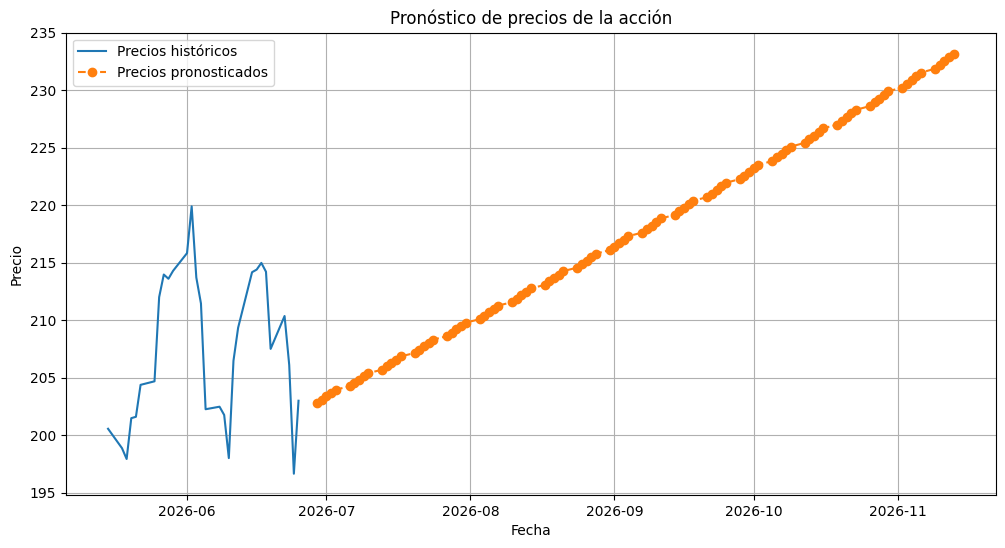

In [208]:
plt.figure(figsize=(12,6))

# Últimos precios históricos
plt.plot(precios.index[-30:], precios[-30:], label='Precios históricos')

# Predicciones
plt.plot(fechas_pred, precios_pred,
         marker='o',
         linestyle='--',
         label='Precios pronosticados')

plt.title('Pronóstico de precios de la acción')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)

plt.show()

###Estadísticos de Bondad de Ajuste